![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [127]:
import warnings
warnings.filterwarnings('ignore')

In [128]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [129]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [130]:
from IPython.display import Markdown, display
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


In [131]:
def tabla_frecuencias(df, col):
    freq = pd.DataFrame({
        'Frecuencia': df[col].value_counts(dropna=False),
        'Porcentaje (%)': (
            df[col].value_counts(normalize=True, dropna=False) * 100
        ).round(2)
    })
    return freq.sort_index()


In [132]:
# Celda 1.1

display(Markdown(
f'''## 1.1 Season:
Season es una variable categorica que representa la estación del año en cada observación.
se distribuye de la sigueinte manera:
'''))

display(tabla_frecuencias(bikes, 'season'))

display(Markdown(
f'''Las observaciones estan mas o menos balanceadas, cada una concentra mas o menos el 25% de
las observaciones, siendo la **season 1** la que tiene menos datos con **2686** observaciones y
un **24.67%**.

Ahora bien, en la base de datos cada observación representa una hora y la variables **total** representa
el total de bicicletas usadas durante ese rango de tiempo. Lo anterior permite explorar el comportamiento
de la variable **total** por **season**.
'''))

season_stats = bikes.groupby('season')['total'].agg([
    'count', 'mean', 'min', 'max', 'median', 'std'
])

season_percentiles = bikes.groupby('season')['total'].quantile([0.25, 0.5, 0.75]).unstack()
season_percentiles.columns = ['p25', 'p50', 'p75'] 
season_full = season_stats.join(season_percentiles)

display(Markdown("Estadísticas completas por **season**:"))
display(season_full.round(2))

display(Markdown(
f'''Al revisar las estadisticas descriptivas de **total** por cada una de las estaciones
se puede observar que el comportamiento de las bibcibletas retadas es diferente segun la estación
del año. Puntualmente, le **season 1** es la que menor renta de biciletas tiene con un promedio
de **116.34** y la **season 3** es la temporada del año en la que mas se rentan biciletas con un
promedio de **234.42**, esto seguramtne responde a razones climaticas o estacionales fuertemente
influenciadas por temporadas de vacaciones. Este comportamiento ocurre no solo en el promedio o
en el minimo y maximo sino tambien en los percentiles de **total** por **season**
'''))


## 1.1 Season:
Season es una variable categorica que representa la estación del año en cada observación.
se distribuye de la sigueinte manera:


,Frecuencia,Porcentaje (%)
season,,
1,2686,24.67
2,2733,25.11
3,2733,25.11
4,2734,25.11


Las observaciones estan mas o menos balanceadas, cada una concentra mas o menos el 25% de
las observaciones, siendo la **season 1** la que tiene menos datos con **2686** observaciones y
un **24.67%**.

Ahora bien, en la base de datos cada observación representa una hora y la variables **total** representa
el total de bicicletas usadas durante ese rango de tiempo. Lo anterior permite explorar el comportamiento
de la variable **total** por **season**.


Estadísticas completas por **season**:

,count,mean,min,max,median,std,p25,p50,p75
season,,,,,,,,,
1,2686,116.34,1,801,78.0,125.27,24.0,78.0,164.0
2,2733,215.25,1,873,172.0,192.01,49.0,172.0,321.0
3,2733,234.42,1,977,195.0,197.15,68.0,195.0,347.0
4,2734,198.99,1,948,161.0,177.62,51.0,161.0,294.0


Al revisar las estadisticas descriptivas de **total** por cada una de las estaciones
se puede observar que el comportamiento de las bibcibletas retadas es diferente segun la estación
del año. Puntualmente, le **season 1** es la que menor renta de biciletas tiene con un promedio
de **116.34** y la **season 3** es la temporada del año en la que mas se rentan biciletas con un
promedio de **234.42**, esto seguramtne responde a razones climaticas o estacionales fuertemente
influenciadas por temporadas de vacaciones. Este comportamiento ocurre no solo en el promedio o
en el minimo y maximo sino tambien en los percentiles de **total** por **season**


In [133]:
# Celda 1.2

display(Markdown(
f'''## 1.2 hour:
**hour** guarda la hora de la observación, se distribuye de la siguiente manera:
'''))

display(tabla_frecuencias(bikes, 'hour'))

display(Markdown(
f'''Similar a la vaiable anterior las observaciones estan mas o menos balanceadas,
cada una representa mas o menos el 4% de las observaciones.

A continuación algunas variables descriptivas respecto al total de bicicletas alquiladas.
'''))

season_stats = bikes.groupby('hour')['total'].agg([
    'count', 'mean', 'min', 'max', 'median', 'std'
])

season_percentiles = bikes.groupby('hour')['total'].quantile([0.25, 0.5, 0.75]).unstack()
season_percentiles.columns = ['p25', 'p50', 'p75'] 
season_full = season_stats.join(season_percentiles)

display(Markdown("Estadísticas completas por **hour**:"))
display(season_full.round(2))

display(Markdown(
f'''De la tabla anterior, podemos observar un comportamiento de alquiler de bicicletas por horas
consitente con una dinamica de actividad general de las personas, en las que a partir de las **8 horas**
se empieza a aumentar el uso de las bicicletas llegando a un pico promedio a las **17 horas**, horario en el
cual empieza a descender el uso hasta llegar a un minimo promedio a las **4 horas**. Se puede
suponer que esto es consiente con horarios laborales y de sueño de las personas.
'''))


## 1.2 hour:
**hour** guarda la hora de la observación, se distribuye de la siguiente manera:


,Frecuencia,Porcentaje (%)
hour,,
0,455,4.18
1,454,4.17
2,448,4.12
3,433,3.98
4,442,4.06
5,452,4.15
6,455,4.18
7,455,4.18
8,455,4.18


Similar a la vaiable anterior las observaciones estan mas o menos balanceadas,
cada una representa mas o menos el 4% de las observaciones.

A continuación algunas variables descriptivas respecto al total de bicicletas alquiladas.


Estadísticas completas por **hour**:

,count,mean,min,max,median,std,p25,p50,p75
hour,,,,,,,,,
0,455,55.14,2,283,41.0,43.62,24.00,41.0,74.50
1,454,33.86,1,168,19.0,34.11,11.00,19.0,46.00
2,448,22.90,1,119,11.0,26.11,5.00,11.0,32.00
3,433,11.76,1,66,6.0,12.67,3.00,6.0,15.00
4,442,6.41,1,28,6.0,4.22,3.00,6.0,9.00
5,452,19.77,1,57,19.0,12.78,8.00,19.0,29.00
6,455,76.26,1,213,75.0,54.75,24.50,75.0,118.00
7,455,213.12,1,596,208.0,159.21,63.00,208.0,334.00
8,455,362.77,8,839,392.0,231.72,133.50,392.0,563.50


De la tabla anterior, podemos observar un comportamiento de alquiler de bicicletas por horas
consitente con una dinamica de actividad general de las personas, en las que a partir de las **8 horas**
se empieza a aumentar el uso de las bicicletas llegando a un pico promedio a las **17 horas**, horario en el
cual empieza a descender el uso hasta llegar a un minimo promedio a las **4 horas**. Se puede
suponer que esto es consiente con horarios laborales y de sueño de las personas.


### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

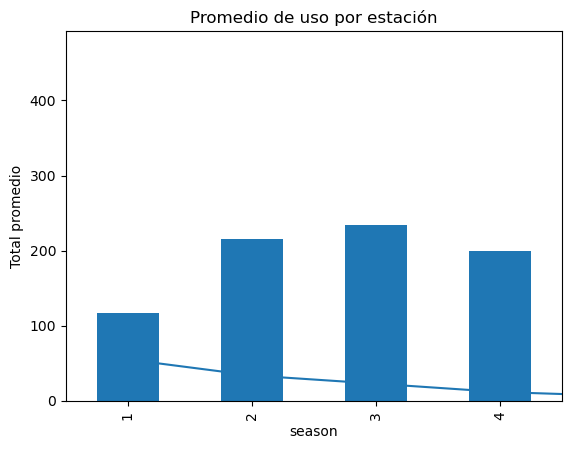

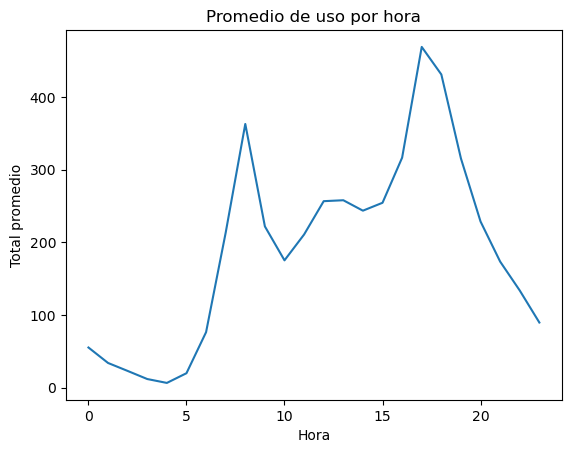

In [134]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

import matplotlib.pyplot as plt

# Promedio por estación
bikes.groupby('season')['total'].mean().plot(kind='bar', title='Promedio de uso por estación')
plt.ylabel('Total promedio')
plt.show()

# Promedio por hora
bikes.groupby('hour')['total'].mean().plot(kind='line', title='Promedio de uso por hora')
plt.ylabel('Total promedio')
plt.xlabel('Hora')
plt.show()

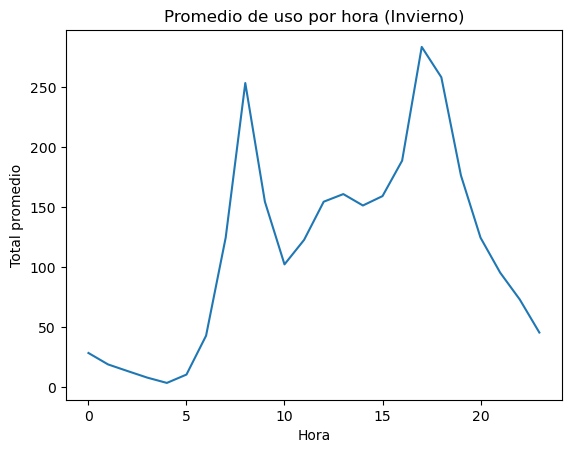

In [135]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 

bikes[bikes['season'] == 1].groupby('hour')['total'].mean().plot(
    kind='line',
    title='Promedio de uso por hora (Invierno)'
)

plt.ylabel('Total promedio')
plt.xlabel('Hora')
plt.show()

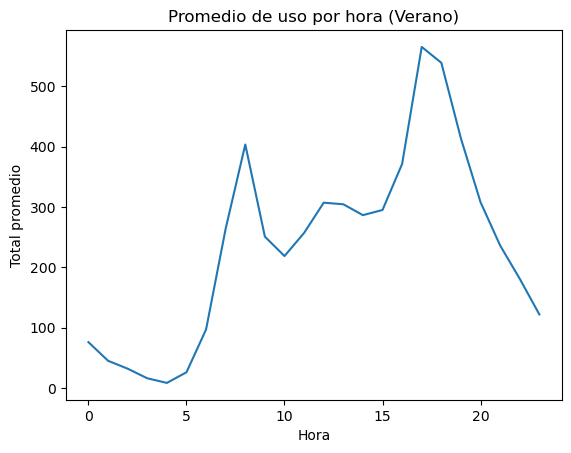

In [136]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 

bikes[bikes['season'] == 3].groupby('hour')['total'].mean().plot(
    kind='line',
    title='Promedio de uso por hora (Verano)'
)

plt.ylabel('Total promedio')
plt.xlabel('Hora')
plt.show()

Consistentemente con el analísis anteriormente presentado, se puede ver como:
- En el grafico de barras se evidencia el menor uso promedio de biciletas en **invierno**
versus **verano**
- El promedio de uso por hora presenta un comportamiento consitente con horarios laborales y de
sueño de las personas, con 2 picos que parecen corresponderse precisamente con hora de llegada y 
de salida laboral, a las **8 horas** y **15 horas** respectivamente. Esta dinamica de comportamiento
es igual para las 2 estaciones analizadas.
- La diferencia entre **invierno** y **verano** respecto al uso de bicicletas por horas redica en
la magnitud, la cantidad de biciletas usadas. Por lo anterior se presenta un grafico unico con el
comportamiento de las 2 estaciones. En este grafico se evidencia que el comportamiento es similar, sin
embargo, durante **verano** en todo el dia se usan mas bicicletas que en **invierno**.


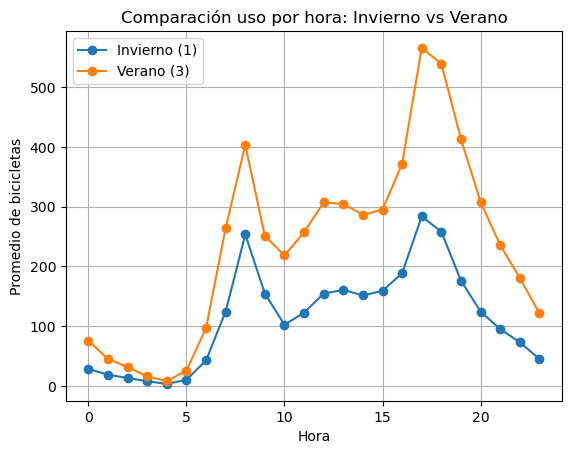

In [137]:
display(Markdown(
f'''Consistentemente con el analísis anteriormente presentado, se puede ver como:
- En el grafico de barras se evidencia el menor uso promedio de biciletas en **invierno**
versus **verano**
- El promedio de uso por hora presenta un comportamiento consitente con horarios laborales y de
sueño de las personas, con 2 picos que parecen corresponderse precisamente con hora de llegada y 
de salida laboral, a las **8 horas** y **15 horas** respectivamente. Esta dinamica de comportamiento
es igual para las 2 estaciones analizadas.
- La diferencia entre **invierno** y **verano** respecto al uso de bicicletas por horas redica en
la magnitud, la cantidad de biciletas usadas. Por lo anterior se presenta un grafico unico con el
comportamiento de las 2 estaciones. En este grafico se evidencia que el comportamiento es similar, sin
embargo, durante **verano** en todo el dia se usan mas bicicletas que en **invierno**.
'''))

winter = bikes[bikes['season'] == 1].groupby('hour')['total'].mean()
summer = bikes[bikes['season'] == 3].groupby('hour')['total'].mean()

plt.figure()
plt.plot(winter, marker='o', label='Invierno (1)')
plt.plot(summer, marker='o', label='Verano (3)')

plt.title('Comparación uso por hora: Invierno vs Verano')
plt.xlabel('Hora')
plt.ylabel('Promedio de bicicletas')
plt.legend()
plt.grid(True)
plt.show()

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [138]:
# Celda 3
display(Markdown(
f'''Para ajustar un modelo de regresión lineal primero se define el tratamiento de las variables:
- Season: Al ser categórica se crea variables dummies que representen cada una de las estaciones
- Hour: Es numerica lineal pero se decide darle el mismo tratamiento que Season, una dummy para cada
hora, esto porque como se conlcuyo anteiormente el efecto de la hora no es lineal y por tanto pasar de
0 a 1 no es lo mismo que de 7 a 9 o de 17 a 18.
'''))

#variable de respuesta y predictoras
X = pd.get_dummies(bikes[['season', 'hour']], columns=['season', 'hour'], drop_first=True)
y = bikes['total']

#separacion test y train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#entranamiento modelo
model = LinearRegression()
model.fit(X_train, y_train)

#predicciones
y_pred = model.predict(X_test)

#evaluacion
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': model.coef_
})

display(Markdown(
f'''
- **R2: {round(r2, 4)}**
- **Intercepto: {round(model.intercept_, 4)}**
- **RMSE: {round(rmse, 4)}**
'''))
display(coef_df)

display(Markdown(
f'''Para el modelo se dividio la muestra en **Train** y **Test** para evaluar no solo ajuste
del modelo sino tambien capacidad predictiva.

De este modo tenemos un R2 de **{round(r2, 4)}**, que al ser un modelo lineal se puede interpretar
como el procentaj de varianza del uso de bicicletas explicado por nuestro modelo. Al no ser
tan alto implica o que un modelo lineal no es la mejor forma de explicar el uso de bibicletas o que
en el error hay variables explicativas imporantes.

Se presentaron lo coeficientes de cada variable dummy, sin embargo, es importante validar significancia
de los mismo si se quiero profundizar en el analísis estadistico.

En terminos de predicción se estimaron los **y** en la muestra de **Test** y se calculo el error cuadratico
medio **RMSE**, para posteriormente compararlo con otros modelos.
'''))

linealR = {
    'rmse': rmse,
    'r2': r2
    }


Para ajustar un modelo de regresión lineal primero se define el tratamiento de las variables:
- Season: Al ser categórica se crea variables dummies que representen cada una de las estaciones
- Hour: Es numerica lineal pero se decide darle el mismo tratamiento que Season, una dummy para cada
hora, esto porque como se conlcuyo anteiormente el efecto de la hora no es lineal y por tanto pasar de
0 a 1 no es lo mismo que de 7 a 9 o de 17 a 18.



- **R2: 0.556**
- **Intercepto: -22.8651**
- **RMSE: 119.8813**


,Variable,Coeficiente
0,season_2,99.972234
1,season_3,118.493410
2,season_4,88.157058
3,hour_1,-20.457762
4,hour_2,-29.082210
5,hour_3,-46.501080
6,hour_4,-48.435352
7,hour_5,-35.508838
8,hour_6,22.871997
9,hour_7,162.841606


Para el modelo se dividio la muestra en **Train** y **Test** para evaluar no solo ajuste
del modelo sino tambien capacidad predictiva.

De este modo tenemos un R2 de **0.556**, que al ser un modelo lineal se puede interpretar
como el procentaj de varianza del uso de bicicletas explicado por nuestro modelo. Al no ser
tan alto implica o que un modelo lineal no es la mejor forma de explicar el uso de bibicletas o que
en el error hay variables explicativas imporantes.

Se presentaron lo coeficientes de cada variable dummy, sin embargo, es importante validar significancia
de los mismo si se quiero profundizar en el analísis estadistico.

En terminos de predicción se estimaron los **y** en la muestra de **Test** y se calculo el error cuadratico
medio **RMSE**, para posteriormente compararlo con otros modelos.


### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [139]:
# Celda 4
# Definición de parámetros y criterios de parada
max_depth = None
num_pct = 10
max_features = None
min_gain=0.001

def mse(y):
    return np.mean((y - y.mean())**2)

def mse_gain(y, y_l, y_r):
    n = len(y)
    return mse(y) - (len(y_l)/n)*mse(y_l) - (len(y_r)/n)*mse(y_r)

# Definición de la función best_split para calcular cuál es la mejor variable y punto de cortepara hacer la bifurcación del árbol
def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    
    best_split = [0, 0, 0]  # j, split, gain
    
    # Para todas las varibles 
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        # Para cada partición
        for split in splits:
            filter_l = X.iloc[:, j] < split
            y_l = y.loc[filter_l]
            y_r = y.loc[~filter_l]
            gain = mse_gain(y, y_l, y_r)

            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    # Si solo es una observación
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[:1].values[0], level=level, split=-1, n_samples=1, gain=0)
        return tree
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = y.mean()
    
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)

    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

#Contar depth
def count_leaves(tree):
    if tree['split'] == -1:
        return 1
    return count_leaves(tree['sl']) + count_leaves(tree['sr'])

def tree_predict(X, tree):
    
    predicted = np.ones(X.shape[0])

    # Revisar si es el nodo final
    if tree['split'] == -1:
        predicted = predicted * tree['y_pred']

    else:
        
        j, split = tree['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:  # Si el nodo izquierdo está vacio solo continua con el derecho 
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
        elif X_r.shape[0] == 0:  #  Si el nodo derecho está vacio solo continua con el izquierdo
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])

    return predicted



In [140]:
X_tree = bikes[['hour', 'season']]
y = bikes['total']

X_train, X_test, y_train, y_test = train_test_split(
    X_tree, y, test_size=0.33, random_state=42
)
tree = tree_grow(
    X_train, 
    y_train, 
    level=0, 
    min_gain=min_gain, 
    max_depth=max_depth, 
    num_pct=num_pct
)

display(Markdown(
f'''
Número de hojas: {count_leaves(tree)}
Este numero de hojas se controlo mediante los hiperparametros.
'''))

#predicciones
y_pred = tree_predict(X_test, tree)


#evaluacion
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


display(Markdown(
f'''
- **R2: {round(r2, 4)}**
- **RMSE: {round(rmse, 4)}**
'''))


display(Markdown(
f'''Para el modelo de arbol manual, se utilizan las variables de base, sin las transformaciones de dummies
ya que el modelo hace particiones directamente. De esta forma se termina con
un arbol con **{count_leaves(tree)}** nodos finales, un **R2** de **{round(r2, 4)}** ligeramente superior al
anterior modelo y un RMSE **{round(rmse, 4)}** ligermante menor, lo que implica que este modelo
tiene mejor capacidad predictiva que el modelo lineal.

'''))

manual_tree = {
    'rmse': rmse,
    'r2': r2
    }


Número de hojas: 95
Este numero de hojas se controlo mediante los hiperparametros.



- **R2: 0.577**
- **RMSE: 117.0226**


Para el modelo de arbol manual, se utilizan las variables de base, sin las transformaciones de dummies
ya que el modelo hace particiones directamente. De esta forma se termina con
un arbol con **95** nodos finales, un **R2** de **0.577** ligeramente superior al
anterior modelo y un RMSE **117.0226** ligermante menor, lo que implica que este modelo
tiene mejor capacidad predictiva que el modelo lineal.



### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.


- **R2: 0.578**
- **RMSE: 116.8738**


Para el modelo de arbol usando scikit-learn, tambien se utilizan las variables de base,
sin las transformaciones de dummies ya que el modelo hace particiones directamente.
De esta forma se termina con un arbol con un **R2** de **0.578** ligeramente superior al
anterior modelo y un RMSE **116.8738** ligermante menor, lo que implica que este modelo
tiene mejor capacidad predictiva que los 2 modelos anteriores.



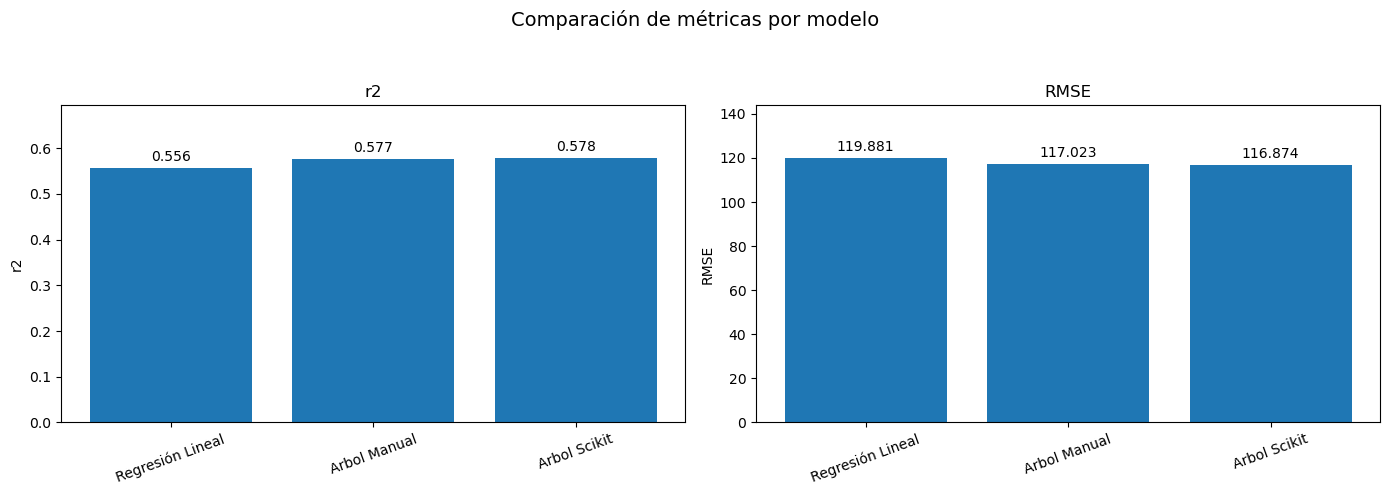

In [141]:
# Celda 5
# Lista de valores para calibrar el criterio de parada de máxima profundidad (max_depth)
max_depth_range = range(1, 21)

# Lista para guardar los valores del RMSE para cada valor de máxima profundidad (max_depth)
rmse_scores = []

# Loop para obtener el desempeño del modelo de acuerdo con la máxima profundidad
for depth in max_depth_range:
    # Definición del árbol de decisión usando DecisionTreeClassifier de la libreria sklearn
    model = DecisionTreeRegressor(max_depth=depth, random_state=1)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=10,
        scoring='neg_mean_squared_error'
    )
    rmse = np.sqrt(-scores.mean())
    rmse_scores.append(rmse)
    
#best depth es el que minimiza el RMSE
best_depth = max_depth_range[np.argmin(rmse_scores)]

#entrenar modelo final
model = DecisionTreeRegressor(max_depth=best_depth, random_state=1)
model.fit(X_train, y_train)

#predicciones
y_pred = model.predict(X_test)

#evaluacion
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

display(Markdown(
f'''
- **R2: {round(r2, 4)}**
- **RMSE: {round(rmse, 4)}**
'''))


display(Markdown(
f'''Para el modelo de arbol usando scikit-learn, tambien se utilizan las variables de base,
sin las transformaciones de dummies ya que el modelo hace particiones directamente.
De esta forma se termina con un arbol con un **R2** de **{round(r2, 4)}** ligeramente superior al
anterior modelo y un RMSE **{round(rmse, 4)}** ligermante menor, lo que implica que este modelo
tiene mejor capacidad predictiva que los 2 modelos anteriores.

'''))

sci_tree = {
    'rmse': rmse,
    'r2': r2
    }

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación de métricas por modelo', fontsize=14)

modelos = ['Regresión Lineal', 'Arbol Manual', 'Arbol Scikit']

resultados = {
    'Regresión Lineal':linealR,
    'Arbol Manual':manual_tree,
    'Arbol Scikit':sci_tree
    }

axs_flat = axs.flatten()

metricas= {
    ('rmse', 'RMSE'),
    ('r2', 'r2')   
}

for ax, (key, titulo) in zip(axs.flatten(), metricas):

    valores = [resultados[m][key] for m in modelos]
    bars = ax.bar(
        modelos,
        valores,
    )

    ymin = 0
    ymax = max(valores) * 1.2
    ax.set_ylim(ymin, ymax)

    ax.set_title(titulo, fontsize=12)
    ax.set_ylabel(titulo)

    ax.bar_label(bars, fmt='%.3f', padding=3)
    ax.tick_params(axis='x', labelrotation=20)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(Markdown(
f"""
"""))

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [142]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [143]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [144]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

 ### Distribución de la variable de respuesta:

,count,percentage
Popular,,
0,2256,0.501333
1,2244,0.498667


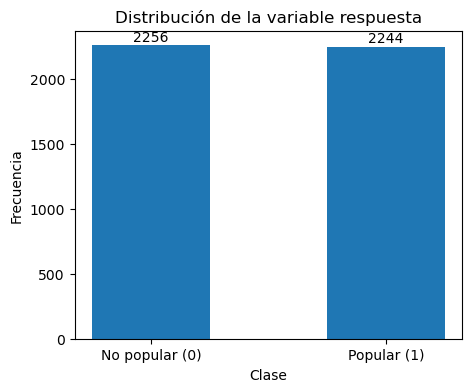

In [145]:
# Analisis de Y
display(Markdown(
f""" ### Distribución de la variable de respuesta:"""))
display(y_train.value_counts().to_frame('count').assign(percentage = lambda x: x/x.sum()))

#frecuencias
conteos = y_train.value_counts().sort_index()

plt.figure(figsize=(5,4))
bars = plt.bar(
    ["No popular (0)", "Popular (1)"],
    conteos,
    width=0.5
)    
plt.bar_label(bars, labels=[str(v) for v in conteos], padding=1)
plt.title("Distribución de la variable respuesta")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [146]:
# Celda 6
display(Markdown(
f'''### Arbol.
'''))

param_grid = {'max_depth': range(1,21)}
tree = DecisionTreeClassifier(random_state=1)

grid_tree = GridSearchCV(
    tree,
    param_grid,
    cv = 10,
    scoring='accuracy'
)
grid_tree.fit(X_train, y_train)

best_tree = grid_tree.best_estimator_

best_depth = grid_tree.best_params_['max_depth']

y_pred = best_tree.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred)
f1_tree = f1_score(y_test, y_pred)

display(Markdown(
f'''El arbol de decisión se calibro el parametro de profundidad y el que mejor acurracy tuvo fue con una
profundidad de **{best_depth}**.

De igual forma, al evaluar el desempeño en la muestra de test se calculan 2 metricas de desempeño.
- Accuracy: **{round(acc_tree, 4)}**: Se intepreta como el porcentaje de predicciones correctas frente al
total de la muestra, es decir que el modelo predice bien el **{100 * round(acc_tree, 4)}%** de las observaciones
- F1 - Score: **{round(f1_tree, 4)}** Se puede intepretar como un balance entre la precisión y el recall.
Cuando las clases estan imbalanceadas puede ser de mayor utilidad ya que no solo evalua si el modelo
predice bien cuando es popular sino tambien considera del total de obs popular cuantas realmente
predice bien el modelo.
'''))

display(Markdown(
f'''### Reg logistica.
'''))

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_log = logreg.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

display(Markdown(
f'''La regresion logistica presento los siguiente resultados:
- Accuracy: **{round(acc_log, 4)}**: Se intepreta como el porcentaje de predicciones correctas frente al
total de la muestra, es decir que el modelo predice bien el **{100 * round(acc_log, 4)}%** de las observaciones
- F1 - Score: **{round(f1_log, 4)}** Se puede intepretar como un balance entre la precisión y el recall.
Cuando las clases estan imbalanceadas puede ser de mayor utilidad ya que no solo evalua si el modelo
predice bien cuando es popular sino tambien considera del total de obs popular cuantas realmente
predice bien el modelo.
'''))



### Arbol.


El arbol de decisión se calibro el parametro de profundidad y el que mejor acurracy tuvo fue con una
profundidad de **1**.

De igual forma, al evaluar el desempeño en la muestra de test se calculan 2 metricas de desempeño.
- Accuracy: **0.6453**: Se intepreta como el porcentaje de predicciones correctas frente al
total de la muestra, es decir que el modelo predice bien el **64.53%** de las observaciones
- F1 - Score: **0.6449** Se puede intepretar como un balance entre la precisión y el recall.
Cuando las clases estan imbalanceadas puede ser de mayor utilidad ya que no solo evalua si el modelo
predice bien cuando es popular sino tambien considera del total de obs popular cuantas realmente
predice bien el modelo.


### Reg logistica.


La regresion logistica presento los siguiente resultados:
- Accuracy: **0.6173**: Se intepreta como el porcentaje de predicciones correctas frente al
total de la muestra, es decir que el modelo predice bien el **61.73%** de las observaciones
- F1 - Score: **0.6068** Se puede intepretar como un balance entre la precisión y el recall.
Cuando las clases estan imbalanceadas puede ser de mayor utilidad ya que no solo evalua si el modelo
predice bien cuando es popular sino tambien considera del total de obs popular cuantas realmente
predice bien el modelo.


### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [147]:
# Celda 7
n_estimators = 300
np.random.seed(123)

n_samples = X_train.shape[0]
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(n_estimators)]

np.random.seed(123) 
seeds = np.random.randint(1, 10000, size=n_estimators)

boost = {}
for i in range(n_estimators):
    if i < 100:
        boost[i] = DecisionTreeClassifier(
            max_features="sqrt",
            max_depth=5,
            random_state=seeds[i])
        boost[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    elif i <200:
        boost[i] = DecisionTreeClassifier(
            max_features="sqrt",
            max_depth=None,
            random_state=seeds[i],
            min_samples_leaf=5
            )
        boost[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])   
    else:
        boost[i] = LogisticRegression(max_iter=1000)
        boost[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])


# Predicción para los datos del set de test con cada modelo
y_pred_df = pd.DataFrame(index=X_test.index, columns=list(range(n_estimators)))
for i in range(n_estimators):
    y_pred_df.iloc[:, i] = boost[i].predict(X_test)

# arboles max_depth
y_pred_1 = (y_pred_df.iloc[:, :100].sum(axis=1) >= 50).astype(int)

# arboles min_samples_leaf
y_pred_2 = (y_pred_df.iloc[:, 100:200].sum(axis=1) >= 50).astype(int)

# regresión logistica
y_pred_3 = (y_pred_df.iloc[:, 200:].sum(axis=1) >= 50).astype(int)

# votación mayoritaria total
y_pred = (y_pred_df.sum(axis=1) >= (n_estimators / 2)).astype(int)

# individualmente
display(Markdown(
f'''
- **Grupo 1 (Arbol depth)**:
    - Accuracy: **{round(accuracy_score(y_test, y_pred_1), 4)}**
    - F1 - Score: **{round(f1_score(y_test, y_pred_1), 4)}** 
- **Grupo 2 (Arbol leaf)**:
    - Accuracy: **{round(accuracy_score(y_test, y_pred_2), 4)}**
    - F1 - Score: **{round(f1_score(y_test, y_pred_2), 4)}** 
- **Grupo 3 log**:
    - Accuracy: **{round(accuracy_score(y_test, y_pred_3), 4)}**
    - F1 - Score: **{round(f1_score(y_test, y_pred_3), 4)}** 
- **TOTAL**:
    - Accuracy: **{round(accuracy_score(y_test, y_pred), 4)}**
    - F1 - Score: **{round(f1_score(y_test, y_pred), 4)}** 

El ensamble mediante votación mayoritaria no mejora el desempeño respecto al mejor
modelo individual, que en este caso es el del primero Arbol. Esto se puede deber a que
que los árboles de decisión que comparten estructuras similares. Adicionalmente,
al incluir un modelo con menor desempeño, como la regresión logística, se introduce ruido en
la votación, debido a que tambien se tiene el mismo peso en todos los modelos.
'''))



- **Grupo 1 (Arbol depth)**:
    - Accuracy: **0.6667**
    - F1 - Score: **0.6667** 
- **Grupo 2 (Arbol leaf)**:
    - Accuracy: **0.6547**
    - F1 - Score: **0.6514** 
- **Grupo 3 log**:
    - Accuracy: **0.6153**
    - F1 - Score: **0.6018** 
- **TOTAL**:
    - Accuracy: **0.6387**
    - F1 - Score: **0.6267** 

El ensamble mediante votación mayoritaria no mejora el desempeño respecto al mejor
modelo individual, que en este caso es el del primero Arbol. Esto se puede deber a que
que los árboles de decisión que comparten estructuras similares. Adicionalmente,
al incluir un modelo con menor desempeño, como la regresión logística, se introduce ruido en
la votación, debido a que tambien se tiene el mismo peso en todos los modelos.


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [148]:
# Celda 8

samples_oob = []
# Obtención de las observaciones fuera de la bolsa "out-of-bag" para cada muestra
for sample in samples:
    samples_oob.append(sorted(set(range(n_samples)) - set(sample)))

# Estimación de los errores OOB para cada clasificador
errors = np.zeros(n_estimators)

for i in range(n_estimators):
    y_pred_ = boost[i].predict(X_train.iloc[samples_oob[i]])
    errors[i] = 1 - metrics.accuracy_score(y_train.iloc[samples_oob[i]], y_pred_)

# Obtención de los pesos alpha de cada modelo de acuerdo al error OOB
alpha = (1 - errors) / (1 - errors).sum()

# Grupo 1
alpha_1 = alpha[:100] / alpha[:100].sum()
weighted_1 = (y_pred_df.iloc[:, :100] * alpha_1).sum(axis=1)
y_pred_1 = (weighted_1 >= 0.5).astype(int)

# Grupo 2
alpha_2 = alpha[100:200] / alpha[100:200].sum()
weighted_2 = (y_pred_df.iloc[:, 100:200] * alpha_2).sum(axis=1)
y_pred_2 = (weighted_2 >= 0.5).astype(int)

# Grupo 3
alpha_3 = alpha[200:] / alpha[200:].sum()
weighted_3 = (y_pred_df.iloc[:, 200:] * alpha_3).sum(axis=1)
y_pred_3 = (weighted_3 >= 0.5).astype(int)

# TOTAL ponderado
weighted_total = (y_pred_df * alpha).sum(axis=1)
y_pred = (weighted_total >= 0.5).astype(int)

display(Markdown(
f'''
- **Grupo 1 (Arbol depth)**:
    - Accuracy: **{round(accuracy_score(y_test, y_pred_1), 4)}**
    - F1 - Score: **{round(f1_score(y_test, y_pred_1), 4)}** 
- **Grupo 2 (Arbol leaf)**:
    - Accuracy: **{round(accuracy_score(y_test, y_pred_2), 4)}**
    - F1 - Score: **{round(f1_score(y_test, y_pred_2), 4)}** 
- **Grupo 3 log**:
    - Accuracy: **{round(accuracy_score(y_test, y_pred_3), 4)}**
    - F1 - Score: **{round(f1_score(y_test, y_pred_3), 4)}** 
- **TOTAL**:
    - Accuracy: **{round(accuracy_score(y_test, y_pred), 4)}**
    - F1 - Score: **{round(f1_score(y_test, y_pred), 4)}** 

En este caso, la votación ponderada asigna mayor peso a los modelos con mejor desempeño
según el error OOB, sin embargo, como los modelos siguen siendo muy correlacionados tenemos
que no mejoran el desempeño global y por tanto sigue siendo mejor quedarse con el primer arbol.
'''))



- **Grupo 1 (Arbol depth)**:
    - Accuracy: **0.6647**
    - F1 - Score: **0.6635** 
- **Grupo 2 (Arbol leaf)**:
    - Accuracy: **0.6547**
    - F1 - Score: **0.6491** 
- **Grupo 3 log**:
    - Accuracy: **0.6153**
    - F1 - Score: **0.6018** 
- **TOTAL**:
    - Accuracy: **0.6367**
    - F1 - Score: **0.6234** 

En este caso, la votación ponderada asigna mayor peso a los modelos con mejor desempeño
según el error OOB, sin embargo, como los modelos siguen siendo muy correlacionados tenemos
que no mejoran el desempeño global y por tanto sigue siendo mejor quedarse con el primer arbol.


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

En la comparación entre la votación mayoritaria y la votación ponderada se observa que el ensamble no logra superar el desempeño del mejor modelo individual, siendo el grupo de arboles con restricción de profundidad el que presenta mejores metricas. La votación mayoritaria alcanza un desempeño intermedio, mientras que la votación ponderada presenta una ligera disminución en el desempeño. En términos generales, la votación mayoritaria tiene la ventaja de ser más simple, mientras que la votación ponderada puede ser mejor si los pesos reflejan adecuadamente la calidad de los modelos. Sin embargo, es sensible a estimaciones ruidosas y a la alta correlación entre modelos, como ocurre en este caso.